# Weekly Training Summary

Loads the consolidated `coach_input_{monday}.json` and displays an interactive overview of the current training week.

In [27]:
import json
from datetime import date, timedelta
from pathlib import Path

import pandas as pd

PROCESSED_DIR = Path("..") / "data" / "processed"

today = date.today()
monday = today - timedelta(days=today.weekday())
input_file = PROCESSED_DIR / f"coach_input_{monday.isoformat()}.json"

if not input_file.exists():
    files = sorted(PROCESSED_DIR.glob("coach_input_*.json"))
    input_file = files[-1]

data = json.loads(input_file.read_text())
print(f"Loaded: {input_file.name}")
print(f"Week starting: {data['week_starting']}")

Loaded: coach_input_2026-04-13.json
Week starting: 2026-04-13


## Athlete Metrics

In [28]:
m = data.get("metrics", {})
weight = m.get("weight") or 0

def w_per_kg(watts):
    if watts and weight:
        return round(watts / weight, 2)
    return None

metrics_display = {
    "FTP (W)": m.get("ftp"),
    "FTP (W/kg)": w_per_kg(m.get("ftp")),
    "Rolling FTP (W)": m.get("rolling_ftp"),
    "Rolling FTP (W/kg)": w_per_kg(m.get("rolling_ftp")),
    "eFTP (W)": round(m.get("eftp", 0), 1),
    "eFTP (W/kg)": w_per_kg(m.get("eftp")),
    "VO2Max (calc.)": m.get("vo2max"),
    "W\u2019 (J)": m.get("w_prime"),
    "Best 5-min Power (W)": m.get("p5min"),
    "Weight (kg)": weight,
    "CTL": round(m.get("ctl", 0), 1),
    "ATL": round(m.get("atl", 0), 1),
    "Resting HR (bpm)": m.get("resting_hr"),
    "HRV": m.get("hrv"),
}

pd.DataFrame(list(metrics_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
FTP (W),265.00
FTP (W/kg),3.51
Rolling FTP (W),260.00
Rolling FTP (W/kg),3.44
eFTP (W),260.00
eFTP (W/kg),3.44
VO2Max (calc.),54.10
W’ (J),18810.00
Best 5-min Power (W),319.00


## Week Summary

In [29]:

ws = data.get("week_summary", {})
tp = ws.get("training_plan")

if tp:
    # Support both old dict format and new list format
    if isinstance(tp, dict):
        tp = [tp]

    rows = []
    for entry in tp:
        week      = entry.get("week", "")
        plan_name = entry.get("plan_name") or "Training Plan"
        phase     = entry.get("phase")
        load      = entry.get("weekly_load_target")
        rows.append({
            "Week":         week,
            "Plan":         plan_name,
            "Phase":        f"#{phase}" if phase else "(no phase)",
            "Phase Period": f"{entry.get('phase_start', '')} → {entry.get('phase_end', '')}",
            "Load Target":  f"{load} TSS" if load is not None else "(none)",
        })

    display(pd.DataFrame(rows).set_index("Week"))
else:
    print("No training plan data available — run get_training_plan.py first.")


,Plan,Phase,Phase Period,Load Target
Week,,,,
2026-04-13,Training Plan,#Build,2026-03-30 → 2026-04-27,461 TSS
2026-04-20,Training Plan,#Build,2026-03-30 → 2026-04-27,339 TSS


In [30]:
ws = data.get("week_summary", {})

week_display = {
    "Rides": ws.get("number_of_rides"),
    "Total Load": ws.get("total_training_load"),
    "Total Time (h)": round(ws.get("total_time_hours", 0), 1),
    "Longest Ride (h)": round(ws.get("longest_ride_hours", 0), 1),
    "VO2 Sessions": ws.get("vo2_sessions"),
    "Threshold Sessions": ws.get("threshold_sessions"),
    "Long Ride Sessions": ws.get("long_ride_sessions"),
    "Endurance Sessions": ws.get("endurance_sessions"),
    "Avg Decoupling (%)": round(ws.get("avg_decoupling", 0), 1),
    "Avg Decoupling Label": ws.get("avg_decoupling_label", ""),
    "Rides with high drift or worse (>=8%)": ws.get("high_decoupling_rides"),
}

pd.DataFrame(list(week_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
Rides,4
Total Load,455
Total Time (h),8.5
Longest Ride (h),4.4
VO2 Sessions,1
Threshold Sessions,0
Long Ride Sessions,1
Endurance Sessions,2
Avg Decoupling (%),7.4


## Activities

In [31]:
activities = data.get("activities", [])
df = pd.DataFrame(activities)

cols = [
    "date", "name", "duration_hours", "ride_type",
    "training_load", "avg_power", "norm_power",
    "polarization_index", "training_distribution",
    "z1_z2_pct", "z3_z4_pct", "z5_plus_pct",
    "decoupling", "rpe", "carbs_used_g", "carbs_ingested_g",
]
cols = [c for c in cols if c in df.columns]
df[cols]


,date,name,duration_hours,training_load,avg_power,norm_power,polarization_index,training_distribution,z1_z2_pct,z3_z4_pct,z5_plus_pct,decoupling,rpe,carbs_used_g,carbs_ingested_g
0,2026-04-06,Easy Todenfeld,3.55,148,143,171,1.38,Pyramidal,81.5,11.2,3.2,14.237227,7.0,432,100
1,2026-04-07,Afternoon Ride,1.87,68,143,160,1.42,Base,90.2,6.3,1.8,-0.109202,4.0,200,0
2,2026-04-08,5 x VO2Max Berrenrath,1.63,81,125,187,2.28,Polarized,80.4,5.2,12.0,28.068396,8.0,261,40
3,2026-04-10,Recovery Ride - Strictly GA1,1.46,53,143,159,1.15,Base,87.4,9.0,1.4,2.792158,NaN,207,35
4,2026-04-11,2 x 17m Scherfbachtal,2.65,136,143,190,0.66,Unique,64.2,24.6,1.6,8.208579,7.0,362,160
5,2026-04-12,Strictly GA1,2.69,97,143,159,0.78,Base,90.2,7.8,0.5,4.303793,4.0,290,240
6,2026-04-14,BTS Mid Tuesday,2.86,169,152,204,1.92,Unique,67.3,12.7,15.0,4.106557,8.0,417,184
7,2026-04-15,REKOM,0.61,25,167,169,0.00,Base,99.9,0.1,0.0,2.032897,NaN,48,24
8,2026-04-16,Lactate-treshold 12m Over-Under,0.65,40,171,208,-0.22,Threshold,51.2,32.8,0.3,11.490194,8.0,146,0
9,2026-04-18,Amstel Gold Race Toerversie mit SweetSpot,4.38,221,141,188,0.62,Threshold,55.8,26.8,1.7,11.866726,5.0,546,400


## Zone Distribution per Activity

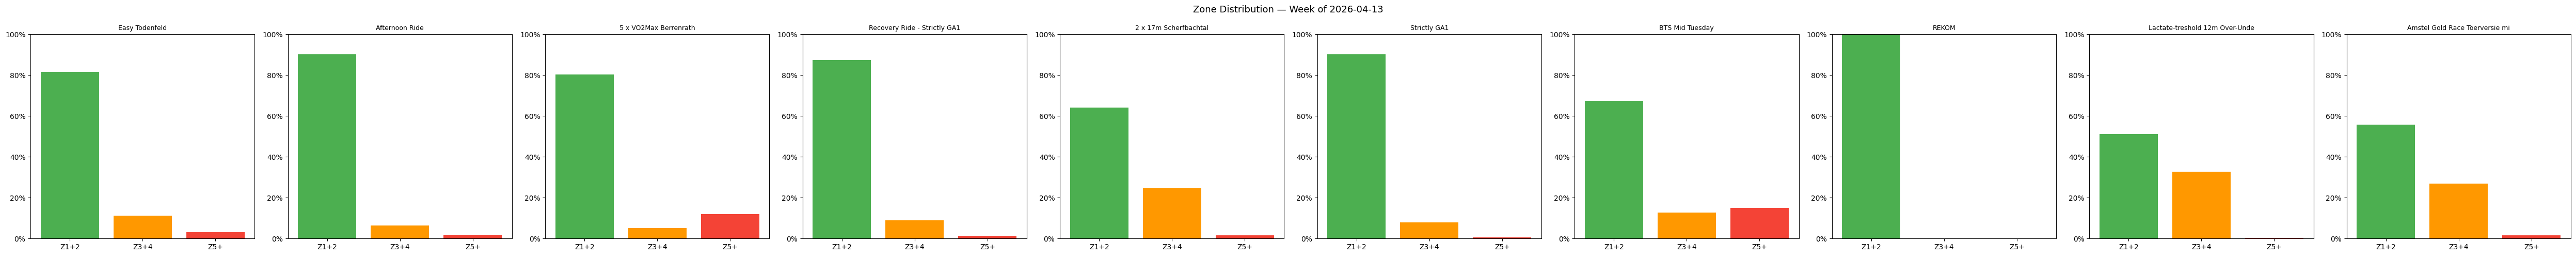

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

zone_df = df[["name", "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]].dropna()
n = len(zone_df)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Zone Distribution \u2014 Week of {data['week_starting']}", fontsize=13)

    for ax, row in zip(axes, zone_df.itertuples()):
        values = [row.z1_z2_pct, row.z3_z4_pct, row.z5_plus_pct]
        labels = ["Z1+2", "Z3+4", "Z5+"]
        colors = ["#4caf50", "#ff9800", "#f44336"]
        ax.bar(labels, values, color=colors)
        ax.set_title(row.name[:30], fontsize=9)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    plt.tight_layout()
    plt.show()

## Training Distribution (Polarization Index)

,Activity,PI,Label,Reason,Z1+2 %,Z3+4 %,Z5+ %
Date,,,,,,,
2026-04-06,Easy Todenfeld,1.38,Pyramidal,"Z1+2 81.5% >= 70%, Z3+4 11.2% >= 10%, Z5+ 3.2%...",81.5,11.2,3.2
2026-04-07,Afternoon Ride,1.42,Base,"Z1+2 90.2% >= 85%, Z3+4 6.3% < 10%, Z5+ 1.8% < 5%",90.2,6.3,1.8
2026-04-08,5 x VO2Max Berrenrath,2.28,Polarized,Z1+2 80.4% >= 70% and Z5+ 12.0% >= 10%,80.4,5.2,12.0
2026-04-10,Recovery Ride - Strictly GA1,1.15,Base,"Z1+2 87.4% >= 85%, Z3+4 9.0% < 10%, Z5+ 1.4% < 5%",87.4,9.0,1.4
2026-04-11,2 x 17m Scherfbachtal,0.66,Unique,"No pattern matched (Z1+2=64.2%, Z3+4=24.6%, Z5...",64.2,24.6,1.6
2026-04-12,Strictly GA1,0.78,Base,"Z1+2 90.2% >= 85%, Z3+4 7.8% < 10%, Z5+ 0.5% < 5%",90.2,7.8,0.5
2026-04-14,BTS Mid Tuesday,1.92,Unique,"No pattern matched (Z1+2=67.3%, Z3+4=12.7%, Z5...",67.3,12.7,15.0
2026-04-15,REKOM,0.00,Base,"Z1+2 99.9% >= 85%, Z3+4 0.1% < 10%, Z5+ 0.0% < 5%",99.9,0.1,0.0
2026-04-16,Lactate-treshold 12m Over-Under,-0.22,Threshold,Z3+4 32.8% >= 25%,51.2,32.8,0.3


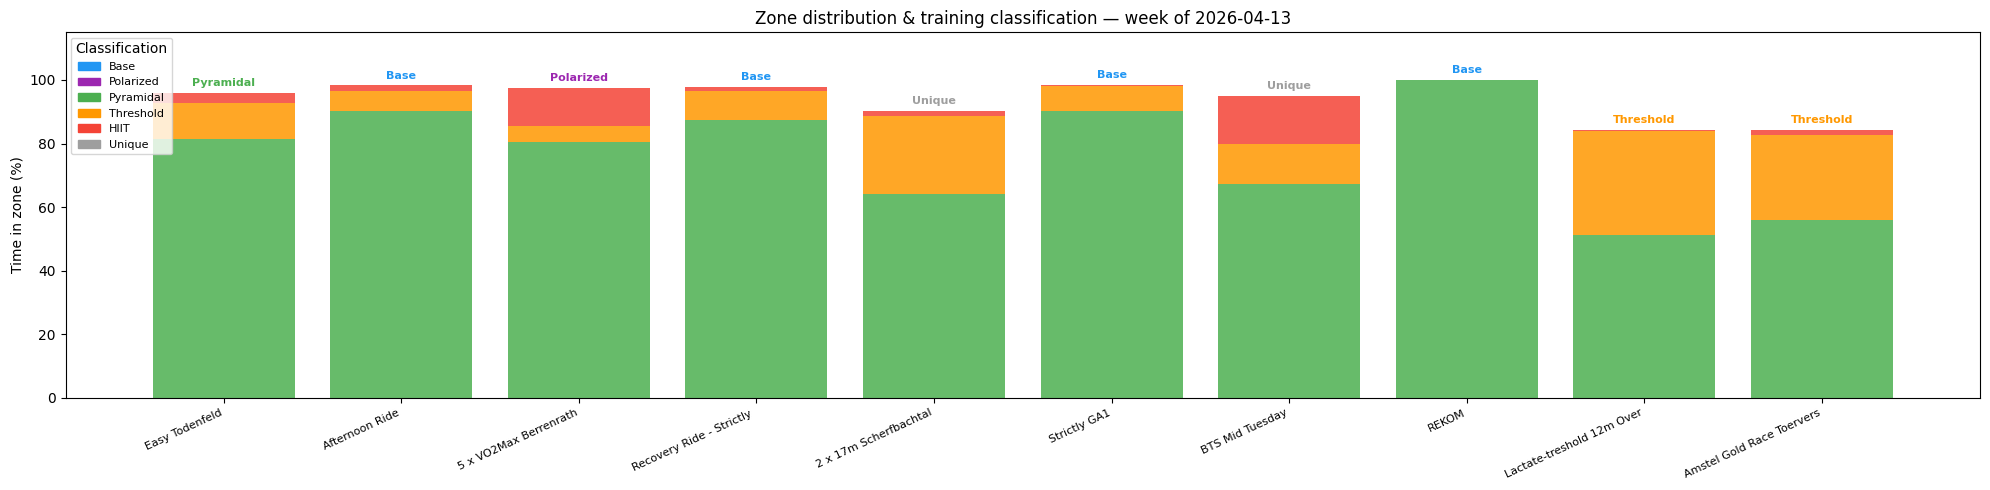


Distribution summary this week:
  Base         4 ride(s)
  Unique       2 ride(s)
  Threshold    2 ride(s)
  Pyramidal    1 ride(s)
  Polarized    1 ride(s)


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dist_df = df[["date", "name", "polarization_index", "training_distribution", "training_distribution_reason",
              "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]].dropna(subset=["training_distribution"])

# --- Table: label + reason per ride ---
if not dist_df.empty:
    display(dist_df.rename(columns={
        "date": "Date",
        "name": "Activity",
        "polarization_index": "PI",
        "training_distribution": "Label",
        "training_distribution_reason": "Reason",
        "z1_z2_pct": "Z1+2 %",
        "z3_z4_pct": "Z3+4 %",
        "z5_plus_pct": "Z5+ %",
    }).set_index("Date"))

    # --- Bar chart: stacked zone distribution coloured by label ---
    LABEL_COLORS = {
        "Base":       "#2196f3",
        "Polarized":  "#9c27b0",
        "Pyramidal":  "#4caf50",
        "Threshold":  "#ff9800",
        "HIIT":       "#f44336",
        "Unique":     "#9e9e9e",
    }

    labels = dist_df["training_distribution"].tolist()
    names  = [str(n)[:25] for n in dist_df["name"].tolist()]
    z1z2   = dist_df["z1_z2_pct"].tolist()
    z34    = dist_df["z3_z4_pct"].tolist()
    z5p    = dist_df["z5_plus_pct"].tolist()
    colors = [LABEL_COLORS.get(l, "#9e9e9e") for l in labels]

    x = range(len(names))
    fig, ax = plt.subplots(figsize=(max(8, 2 * len(names)), 5))
    bars1 = ax.bar(x, z1z2, label="Z1+2", color="#4caf50", alpha=0.85)
    bars2 = ax.bar(x, z34,  bottom=z1z2, label="Z3+4", color="#ff9800", alpha=0.85)
    bars3 = ax.bar(x, z5p,  bottom=[a + b for a, b in zip(z1z2, z34)], label="Z5+", color="#f44336", alpha=0.85)

    # Annotate label above each bar group
    for i, (lbl, col) in enumerate(zip(labels, colors)):
        total = z1z2[i] + z34[i] + z5p[i]
        ax.text(i, total + 1.5, lbl, ha="center", va="bottom", fontsize=8,
                fontweight="bold", color=col)

    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("Time in zone (%)")
    ax.set_ylim(0, 115)
    ax.set_title(f"Zone distribution & training classification — week of {data.get('week_starting', '')}")
    ax.legend(loc="upper right")

    # Legend patches for classification colours
    patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
    ax.legend(handles=patches, loc="upper left", fontsize=8, title="Classification")

    plt.tight_layout()
    plt.show()

    # --- Summary: how many rides per label this week ---
    print("\nDistribution summary this week:")
    for lbl, cnt in dist_df["training_distribution"].value_counts().items():
        print(f"  {lbl:<12} {cnt} ride(s)")
else:
    print("No training_distribution data available — run prepare_activities_for_coach.py first.")


## Form & Fatigue Analysis

In [34]:
ctl = data.get("metrics", {}).get("ctl") or 0
atl = data.get("metrics", {}).get("atl") or 0
hrv = data.get("metrics", {}).get("hrv")
ws = data.get("week_summary", {})

form_absolute = ws.get("form_absolute")
form_pct = ws.get("form_pct")
form_percent_display = ws.get("form_percent_display")
form_zone = ws.get("form_zone", "n/a")

form_display = {
    "CTL (Fitness)": round(ctl, 1),
    "ATL (Fatigue)": round(atl, 1),
    "Form (absolute)": form_absolute,
    "Form (%)": f"{form_percent_display:.1f}%" if form_percent_display is not None else "n/a",
    "Form Zone": form_zone,
    "HRV": hrv,
}

display(pd.DataFrame(list(form_display.items()), columns=["Metric", "Value"]).set_index("Metric"))

print("\n=== Coaching Interpretation ===")
# Zones based on form_pct (%), matching intervals.icu definition
if form_pct is not None:
    if form_pct > 0.20:
        print("Form:  Transition (> 20 %) → well rested, consider increasing load")
    elif form_pct >= 0.05:
        print("Form:  Fresh (5–20 %) → race-ready or high-intensity sessions")
    elif form_pct >= -0.10:
        print("Form:  Grey Zone (-10 to 5 %) → moderate fatigue, maintain structure")
        if hrv is not None and hrv < 50:
            print("HRV:   Low HRV signal → consider an easier day")
    elif form_pct >= -0.30:
        print("Form:  Optimal training zone (-30 to -10 %) → proceed with key sessions")
        if hrv is not None and hrv < 50:
            print("HRV:   Strong fatigue signal combined with low HRV → recommend rest day")
    else:
        print("Form:  High fatigue (below -30 %) → reduce intensity and prioritize recovery")
        if hrv is not None and hrv < 50:
            print("HRV:   Strong fatigue signal combined with low HRV → recommend rest day")
else:
    print("Form data not available — run prepare_week_for_coach.py first.")


,Value
Metric,
CTL (Fitness),61.6
ATL (Fatigue),69.2
Form (absolute),-7.6
Form (%),-12.3%
Form Zone,optimal
HRV,84.0



=== Coaching Interpretation ===
Form:  Optimal training zone (-30 to -10 %) → proceed with key sessions


## Form & Fatigue History

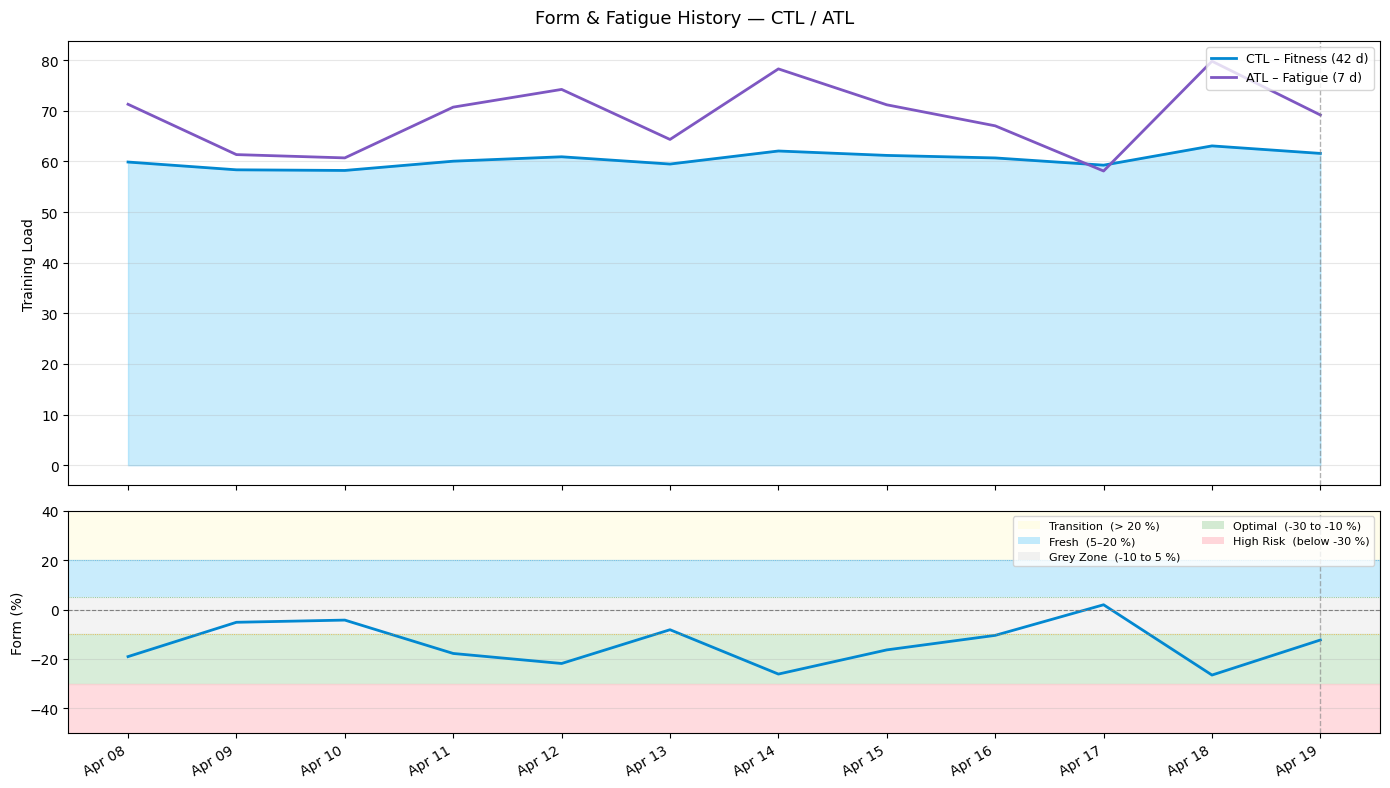


Data points: 12  |  Range: 2026-04-08 → 2026-04-19
Today  →  CTL: 61.6  |  ATL: 69.2  |  Form: -12.3%


In [35]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Load all available metrics snapshots from data/processed/
metrics_files = sorted(PROCESSED_DIR.glob("metrics_*.json"))
hist = []
for f in metrics_files:
    try:
        d = json.loads(f.read_text())
        if d.get("ctl") is not None and d.get("atl") is not None:
            hist.append(d)
    except Exception:
        pass

if len(hist) >= 2:
    dates     = [pd.to_datetime(d["date"]) for d in hist]
    ctl_vals  = [d["ctl"]  for d in hist]
    atl_vals  = [d["atl"]  for d in hist]
    # form_pct in % (matching intervals.icu zone definitions)
    form_vals = [(d["ctl"] - d["atl"]) / d["ctl"] * 100 if d["ctl"] else 0 for d in hist]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )
    fig.suptitle("Form & Fatigue History — CTL / ATL", fontsize=13)

    # ── Top panel: CTL filled area + ATL line ──
    ax1.fill_between(dates, ctl_vals, alpha=0.25, color="#29b6f6")
    ax1.plot(dates, ctl_vals, color="#0288d1", linewidth=2, label="CTL – Fitness (42 d)")
    ax1.plot(dates, atl_vals, color="#7e57c2", linewidth=2, label="ATL – Fatigue (7 d)")
    ax1.set_ylabel("Training Load")
    ax1.legend(loc="upper right", fontsize=9)
    ax1.grid(axis="y", alpha=0.3)

    # ── Bottom panel: form zones (form_pct %, intervals.icu) + form line ──
    ax2.axhspan( 20,  50, color="#fffde7", alpha=0.80, zorder=0)   # Transition (light yellow)
    ax2.axhspan(  5,  20, color="#b3e5fc", alpha=0.70, zorder=0)   # Fresh (light blue)
    ax2.axhspan(-10,   5, color="#eeeeee", alpha=0.70, zorder=0)   # Grey Zone
    ax2.axhspan(-30, -10, color="#c8e6c9", alpha=0.70, zorder=0)   # Optimal (green)
    ax2.axhspan(-60, -30, color="#ffcdd2", alpha=0.70, zorder=0)   # High Risk (red)

    ax2.plot(dates, form_vals, color="#0288d1", linewidth=2, label="Form (%)")
    ax2.axhline(0,  color="grey",    linewidth=0.8, linestyle="--")
    ax2.axhline( 5, color="#4caf50", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.axhline(20, color="#29b6f6", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.axhline(-10, color="#ff9800", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.set_ylabel("Form (%)")
    ax2.set_ylim(-50, 40)

    legend_els = [
        Patch(facecolor="#fffde7", alpha=0.9, label="Transition  (> 20 %)"),
        Patch(facecolor="#b3e5fc", alpha=0.8, label="Fresh  (5–20 %)"),
        Patch(facecolor="#eeeeee", alpha=0.8, label="Grey Zone  (-10 to 5 %)"),
        Patch(facecolor="#c8e6c9", alpha=0.8, label="Optimal  (-30 to -10 %)"),
        Patch(facecolor="#ffcdd2", alpha=0.8, label="High Risk  (below -30 %)"),
    ]
    ax2.legend(handles=legend_els, loc="upper right", fontsize=8, ncol=2)
    ax2.grid(axis="y", alpha=0.3)

    # Set ticks only at actual data dates to avoid duplicates with sparse history
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    if len(dates) <= 60:
        ax2.set_xticks(dates)
    else:
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha="right")

    # Mark today
    today_ts = pd.Timestamp.today().normalize()
    for ax in (ax1, ax2):
        ax.axvline(today_ts, color="grey", linewidth=1, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    print(f"\nData points: {len(hist)}  |  Range: {hist[0]['date']} → {hist[-1]['date']}")
    print(f"Today  →  CTL: {ctl_vals[-1]:.1f}  |  ATL: {atl_vals[-1]:.1f}  |  Form: {form_vals[-1]:.1f}%")
else:
    print(f"Not enough historical data ({len(hist)} snapshot(s) found).")
    print("Run get_metrics.py on multiple days to build up a history.")


## Integrated Fatigue & Fueling Analysis

In [36]:
ff = ws.get("fueling_form_analysis", {})

if ff:
    form_pct_display = ws.get('form_percent_display', 0)
    interpretation = ff.get('interpretation', '')
    recommendation = ff.get('recommendation', '')
    long_ride_advice = ff.get('long_ride_advice')

    ff_display = {
        "Form (%)": f"{form_pct_display:.1f}%",
        "Fatigue Status": ff.get("fatigue_status"),
        "Avg Carbs/h (g)": ff.get("avg_carbs_per_hour"),
        "Fueling Status": ff.get("fueling_status"),
        "Underfueled Sessions": ff.get("underfueled_sessions"),
        "Durability Limited by Fueling": ff.get("durability_limited_by_fueling"),
        "Long Rides": ff.get("number_of_long_rides"),
    }
    display(pd.DataFrame(list(ff_display.items()), columns=["Metric", "Value"]).set_index("Metric"))
    print()
    print(f"Interpretation: {interpretation}")
    print(f"Recommendation: {recommendation}")
    if long_ride_advice:
        print(f"Long rides:     {long_ride_advice}")
else:
    print("No integrated analysis available — run prepare_week_for_coach.py first.")


,Value
Metric,
Form (%),-12.3%
Fatigue Status,optimal
Avg Carbs/h (g),60.5
Fueling Status,moderate
Underfueled Sessions,1
Durability Limited by Fueling,True
Long Rides,4



Interpretation: Fatigue is appropriate and productive
Recommendation: Continue with planned VO2 and threshold sessions
Long rides:     Focus on fueling during long rides (80–90 g/h)


## Fueling Analysis

In [37]:
fueling = data.get("fueling_analysis", {})
fa = fueling.get("activities", [])

if fa:
    df_fuel = pd.DataFrame(fa)
    fuel_cols = [
        "date", "name", "duration_hours", "fueling_status", "ride_type",
        "carbs_per_hour", "carbs_classification", "fueling_ratio",
        "ratio_classification", "is_long_ride", "flags",
    ]
    fuel_cols = [c for c in fuel_cols if c in df_fuel.columns]
    display(df_fuel[fuel_cols])

    fs = fueling.get("weekly_summary", {})
    print(f"\nLong rides:           {fs.get('number_of_long_rides')}")
    print(f"Avg carbs/h:          {fs.get('avg_carbs_per_hour')} g")
    print(f"Avg fueling ratio:    {fs.get('avg_fueling_ratio')}")
    print(f"Underfueled sessions: {fs.get('number_of_underfueled_sessions')}")

    print("\nRecommendations:")
    for r in fueling.get("recommendations", []):
        print(f"  * {r}")

,date,name,duration_hours,fueling_status,ride_type,carbs_per_hour,carbs_classification,fueling_ratio,ratio_classification,is_long_ride,flags
0,2026-04-06,Easy Todenfeld,3.55,fueling required,long_ride,28.2,very low,0.23,severe deficit,True,"[underfueled long ride, decoupling likely caus..."
1,2026-04-07,Afternoon Ride,1.87,fueling optional,endurance,0.0,optional,0.00,optional,False,[]
2,2026-04-08,5 x VO2Max Berrenrath,1.63,fueling optional,vo2,24.5,optional,0.15,optional,False,[]
3,2026-04-10,Recovery Ride - Strictly GA1,1.46,no fueling needed,recovery,24.0,not required,0.17,not applicable,False,[]
4,2026-04-11,2 x 17m Scherfbachtal,2.65,fueling required,endurance,60.4,moderate,0.44,moderate deficit,True,[]
5,2026-04-12,Strictly GA1,2.69,fueling required,long_ride,89.2,good,0.83,good,True,[]
6,2026-04-14,BTS Mid Tuesday,2.86,fueling required,vo2,64.3,moderate,0.44,moderate deficit,True,[]
7,2026-04-15,REKOM,0.61,no fueling needed,recovery,39.3,not required,0.50,not applicable,False,[]
8,2026-04-16,Lactate-treshold 12m Over-Under,0.65,no fueling needed,endurance_with_sprint,0.0,not required,0.00,not applicable,False,[]
9,2026-04-18,Amstel Gold Race Toerversie mit SweetSpot,4.38,fueling required,endurance_with_sprint,91.3,good,0.73,good,False,[]



Long rides:           4
Avg carbs/h:          60.5 g
Avg fueling ratio:    0.48
Underfueled sessions: 1

Recommendations:
  * Increase fueling on long rides — target at least 60 g/h.
  * Target 80–90 g/h on long rides (> 2 h).
  * Fueling likely limiting aerobic durability — address carbohydrate intake on longer sessions.
  * Short rides do not require fueling — focus on long sessions.
